In [ ]:
library(ggplot2)
library(ggpubr)
library(Seurat)
library(ComplexHeatmap)
library(colorRamps)
library(circlize)
library(dplyr)


Loading required package: SeuratObject

Loading required package: sp


Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t


Loading required package: grid

ComplexHeatmap version 2.20.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github pag

Warning message:
"The input is a data frame-like object, convert it to a matrix."
`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



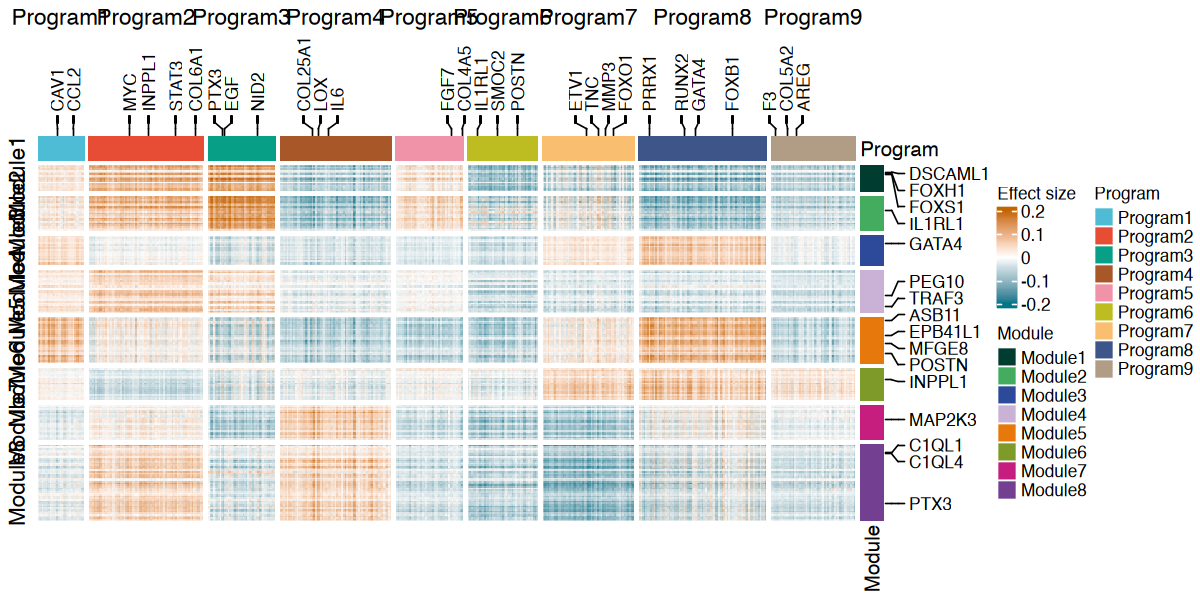

In [2]:
highlight_pts <- c(
  "DSCAML1","FOXS1","FOXH1","IL1RL1","LPS1",
  "PEG10","TRAF3","GATA4","ASB11","EPB41L1",
  "MFGE8","POSTN","INPPL1","MAP2K3","C1QL1",
  "C1QL4","PTX3"
)

highlight_genes<-c(
  "CAV1","CCL2","MYC","INPPL1","STAT3","COL6A1",
  "PTX3","EGF","NID2","COL25A1","IL6","LOX","FGF7",
  "COL4A5","IL1RL1","SMOC2", "POSTN","ETV1","TNC",
  "MMP3","FOXO1","PRRX1","RUNX2","GATA4",
  "FOXB1","F3","COL5A2","AREG"
)

effectMat<-read.csv('Effect_size_filtered.csv',
                    header = T,
                    check.names = F,
                    row.names = 1)
geneProgram<-read.table("geneProgram.txt",
                      header = T,sep="\t",
                      check.names = F)
pertubation<-read.table("perturbationModule.txt",
                      header = T,sep="\t",
                      check.names = F)


pt=rownames(effectMat)
ptindex<-which(pt%in%highlight_pts)
ptlabels<-pt[ptindex]


gp=colnames(effectMat)
gpindex<-which(gp%in%highlight_genes)
gplabs<-gp[gpindex]

colanno=data.frame(Program=geneProgram$Program,row.names =geneProgram$gene)
rowanno=data.frame(Module=pertubation$Module,row.names = pertubation$gene)

rowcol <- list(
  Module = c(
    Module1 = "#003C30",
    Module2 = "#43AC5E",
    Module3 = "#2D4999",
    Module4 = "#C9B2D6",
    Module5 = "#E6780C",
    Module6 = "#7E9A29",
    Module7 = "#C51E7E",
    Module8 = "#723F91"
  )
)


colcol <- list(
  Program = c(
    Program1 = "#4EBCD5",
    Program2 = "#E74C35",
    Program3 = "#07A087",
    Program4 = "#A75728",
    Program5 = "#F193A8",
    Program6 = "#BDBD21",
    Program7 = "#FABE70",
    Program8 = "#3D5589",
    Program9 = "#B19D86"
  )
)

rowanno<-rowAnnotation(Module=rowanno$Module,
                       col=rowcol,
                       Perturbation=anno_mark(at=ptindex,
                                              labels=ptlabels,
                                              labels_gp=gpar(fontsize=10),
                                              lines_gp=gpar()
                                              )
                       
)

colanno = HeatmapAnnotation(Genes=anno_mark(at=gpindex,
                                            labels=gplabs,
                                            labels_gp=gpar(fontsize=10),
                                            side = "top",
                                            lines_gp=gpar()),
                            Program = colanno$Program,
                            col=colcol)

color =colorRamp2(c(-0.2,-0, 0.2), c("#00768B","white", "#C36600"))
effectMat[effectMat>0.2]=0.2
effectMat[effectMat<(-0.2)]=-0.2

options(repr.plot.width = 10, repr.plot.height =5)
p1=ComplexHeatmap::Heatmap(effectMat,
                           show_row_names = FALSE, 
                           name="Effect size",
                           show_column_names = FALSE, 
                           show_column_dend = FALSE,
                           cluster_columns = F,
                           cluster_row_slices =T, 
                           cluster_rows = F,
                           col=color,
                           row_split = pertubation$Module,
                           column_split=geneProgram$Program ,
                           top_annotation =colanno,
                           right_annotation = rowanno)
                        
draw(p1)


Warning message:
"Using `bins = 30` by default. Pick better value with the argument `bins`."
Warning message:
"Removed 1183916 rows containing non-finite outside the scale range
(`stat_bin()`)."


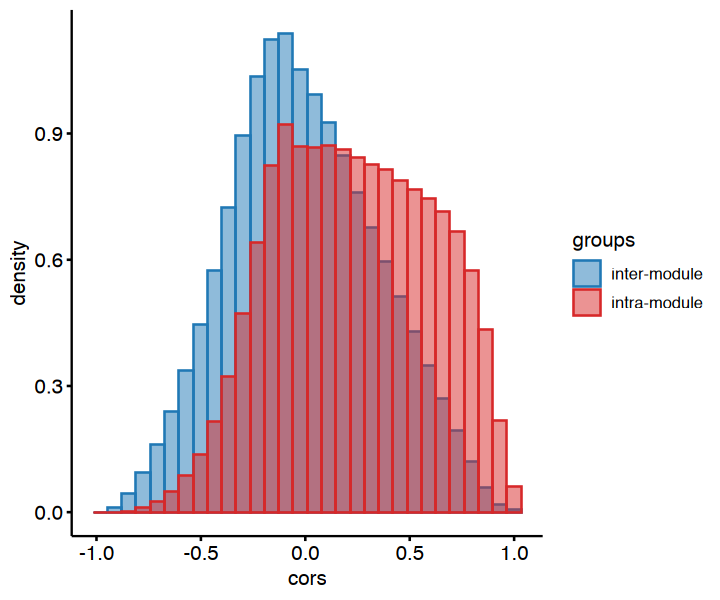

In [3]:
options(repr.plot.width = 6, repr.plot.height =5)
gene_cor<-read.csv("gene_program_expression_correlation.csv",header = T,row.names = 1,check.names = F)
 
pp=gghistogram(gene_cor,x="cors",y="density",
               color = "groups",fill = "groups",
               legend="right",
               palette = c(c("#2078B5","#D72829")))
pp

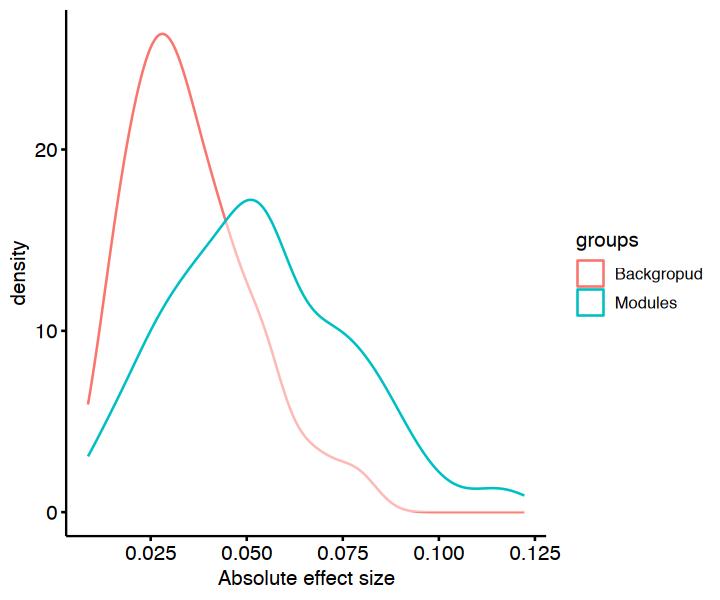

In [ ]:
options(repr.plot.width = 6, repr.plot.height =5)
effectsize$groups <- gsub("intra_module","Modules", effectsize$groups)
effectsize$groups <- gsub("inter_module","Backgropud", effectsize$groups)
ggdensity(effectsize,
        x="MaxValue",
        color = "groups",
        legend="right",
        xlab = "Absolute effect size",
    
        )

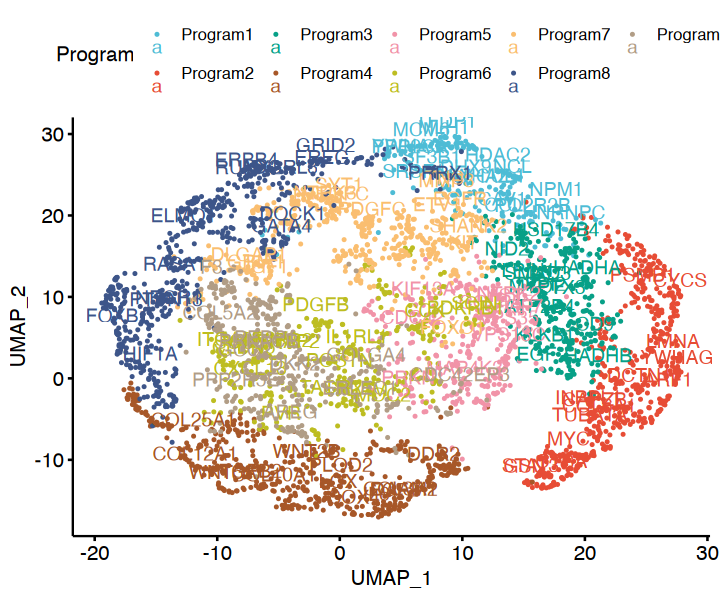

In [5]:
showGenes<- c(
  "DHX9","YWHAQ","MCM6","SF3B1","NCL","MLH1","POLR2B",
  "PPP2CA","NPM1","HDAC2","CUL1","YWHAZ","TFDP1",
  "HNRNPC","SRSF1","CAPZB","LMNA","ARF1","DCTN1",
  "PSMB1","CYCS","YWHAG","GSN","TUBA1A","CTSA","ATP2B4","LPIN1",
  "HADHA","HADHB","KLKB1","HSD17B4","TFPI2","MYOF",
  "CD9","SMAD3","WNT2B","DDR2","TGFB2","COL3A1","WNT5A","PLOD2",
  "FGF2","LOX","SOX4","DAAM2","COL12A1","COL10A1",
  "CDC42","LYST","MAP4K3","KIF13A","PRKN","NTRK2","FGF7",
  "VPS13C","VPS35","ITGA9","CCK","SUCNR1","CXCL13",
  "SCIN","CNTNAP2","VIPR2","TACR2","BDKRB1","MAP2K1","CLDN6",
  "ITGAM","PVR","PDGFB","KIT","PDGFC","VEGFC","GRIA1",
  "EGFR","SHANK2","SYT1","IGF1","NTRK3","DLGAP1","NEGR1",
  "ERBB4","ADGRL3","EREG","PTPN13","GRID2","RASA1","ELMO1",
  "DOCK1","HIF1A","PRKACB","CDC42EP3","ERLEC1","GCC2",
  "GOLGA4","AREG","DKK2","PEBP1","PPP2R5E","CAV1","CCL2",
  "MYC","INPPL1","STAT3","COL6A1","PTX3","EGF","NID2",
  "COL25A1","IL6","COL4A5","IL1RL1","SMOC2","POSTN",
  "ETV1","TNC","MMP3","FOXO1","PRRX1","RUNX2","GATA4","FOXB1",
  "F3","COL5A2"
)

geneProgramColor <-c( "#4EBCD5", "#E74C35","#07A087", "#A75728",
                      "#F193A8","#BDBD21", "#FABE70", "#3D5589", "#B19D86")

p=ggscatter(geneProgram,
            x="UMAP_1",
            y="UMAP_2",
            color = "Program",
            size=0.3,
            
            label = "gene",
            label.select = showGenes,
            palette=geneProgramColor 
            )
print(p)

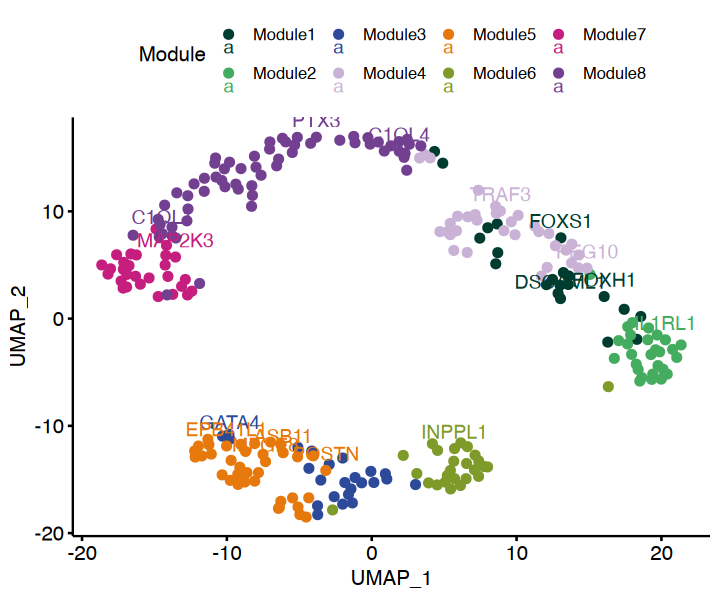

In [6]:
modulecol <- c("#003C30", "#43AC5E", "#2D4999", "#C9B2D6", 
               "#E6780C", "#7E9A29","#C51E7E", "#723F91")
p=ggscatter(pertubation,
            x="UMAP_1",
            y="UMAP_2",
            color = "Module",
            size=2,
            label = "Pertubation",
           label.select =highlight_pts ,
            palette=modulecol )
p